In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
from pathlib import Path

In [2]:
# Load trajectory
OUTPUT_DIR = Path('../test07/output')
TRAJ_PATH = Path('../test07/traj_skip100NoH.xtc')
TOP_PATH = Path('../test07/2JOF-0-proteinNoH.pdb')

pdb = md.load(str(TOP_PATH))
traj = md.load(str(TRAJ_PATH), top=pdb)
cvs = np.load(OUTPUT_DIR / 'latents.npy')

cv1, cv2 = cvs[:,0], cvs[:,1]

# Add path for pkgs to use robust alignment
import sys
from pathlib import Path
sys.path.append(str(Path('../../').resolve()))
from pkgs.utils import compute_aligned_phi_psi

phi, psi, residue_ids, _ = compute_aligned_phi_psi(traj)
print(f"Aligned residues: {residue_ids}")


Aligned residues: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


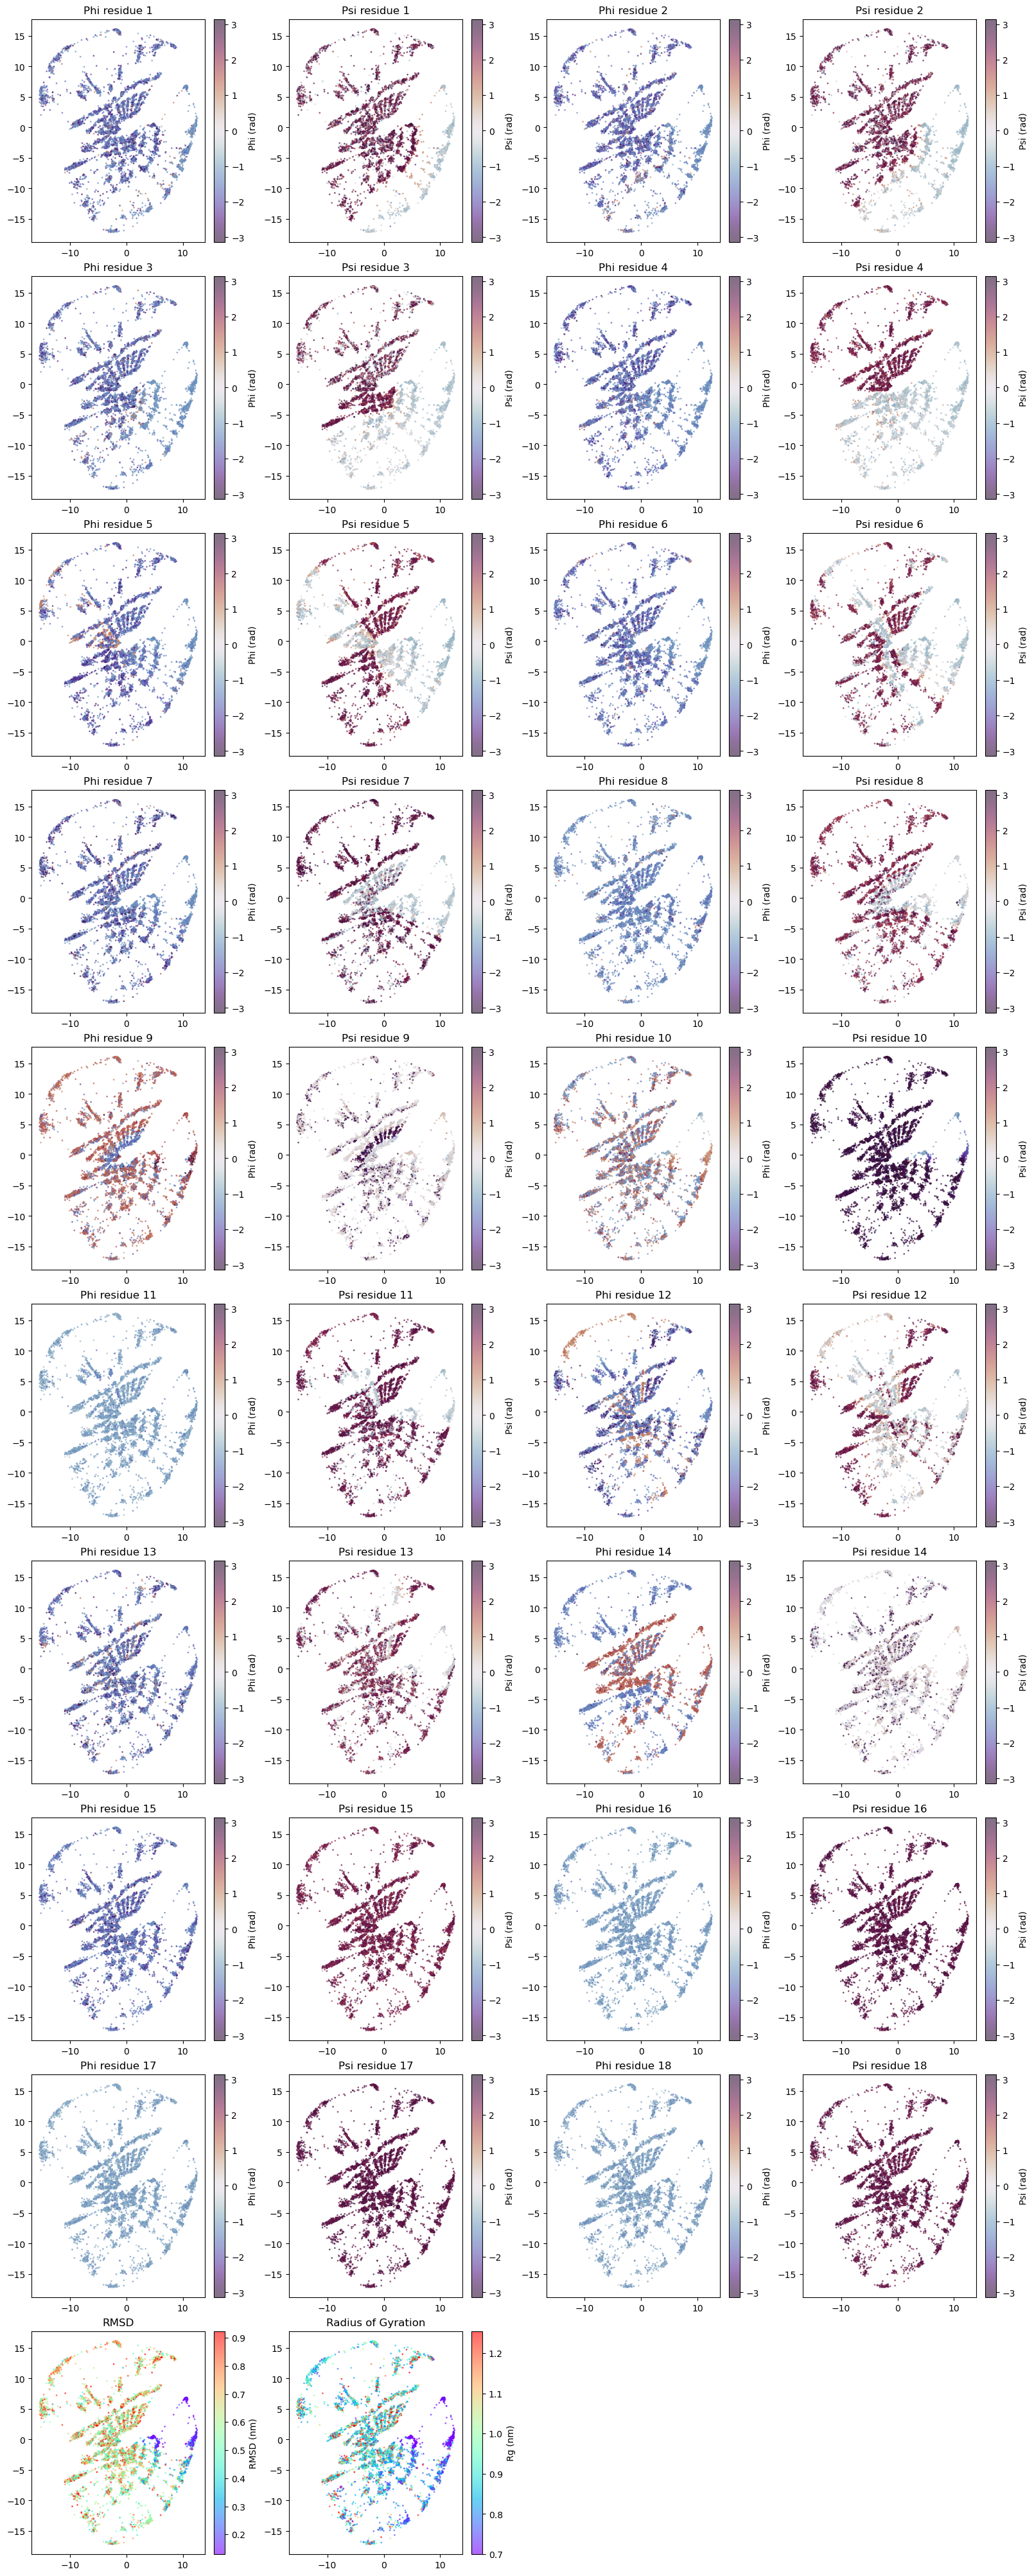

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Reset completo (evita che restino stili "dark" attivi)
mpl.rcdefaults()
plt.style.use("default")

# Forza background bianco + testi neri
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

# --- Calcoli ---
# (Already computed above using robust alignment)
# RMSD: use backbone-only + fit to reference
bb_idx = traj.topology.select("backbone")
rmsd = md.rmsd(traj, pdb, 0, atom_indices=bb_idx)
rg   = md.compute_rg(traj)

cv1 = cvs[:, 0]
cv2 = cvs[:, 1]

# robust color scale to avoid rare states being washed out
rmsd_vmin, rmsd_vmax = np.percentile(rmsd, [5, 95])
rg_vmin, rg_vmax = np.percentile(rg, [5, 95])

# Focus on Top residues from MI analysis if needed, 
# but for now let's just fix the plotting logic to show BOTH phi and psi
# and use the correct residue IDs.

n_res = len(residue_ids)

# --- Layout subplot ---
# Plotting both Phi and Psi for each residue
n_plots = n_res * 2 + 2
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)

axes = np.array(axes).ravel()

# --- Plot phi and psi ---
plot_idx = 0
for i in range(n_res):
    res_id = residue_ids[i]
    
    # Phi
    ax = axes[plot_idx]
    sc = ax.scatter(cv1, cv2, c=phi[:, i], cmap="twilight_shifted", s=1, alpha=0.6, vmin=-np.pi, vmax=np.pi)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Phi (rad)")
    ax.set_title(f"Phi residue {res_id}")
    plot_idx += 1
    
    # Psi
    ax = axes[plot_idx]
    sc = ax.scatter(cv1, cv2, c=psi[:, i], cmap="twilight_shifted", s=1, alpha=0.6, vmin=-np.pi, vmax=np.pi)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Psi (rad)")
    ax.set_title(f"Psi residue {res_id}")
    plot_idx += 1

# --- RMSD ---
ax = axes[plot_idx]
sc = ax.scatter(cv1, cv2, c=rmsd, cmap="rainbow", s=1, alpha=0.6, vmin=rmsd_vmin, vmax=rmsd_vmax)
fig.colorbar(sc, ax=ax).set_label("RMSD (nm)")
ax.set_title("RMSD")
plot_idx += 1

# --- Rg ---
ax = axes[plot_idx]
sc = ax.scatter(cv1, cv2, c=rg, cmap="rainbow", s=1, alpha=0.6, vmin=rg_vmin, vmax=rg_vmax)
fig.colorbar(sc, ax=ax).set_label("Rg (nm)")
ax.set_title("Radius of Gyration")
plot_idx += 1

# --- Spegni gli assi "vuoti" (se la griglia è più grande del numero di plot) ---
for j in range(n_plots, n_rows * n_cols):
    axes[j].axis("off")

# --- Salvataggio ---
fig.savefig("cv_analysis-by-psi.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()



In [4]:
h = np.loadtxt('/home/tedeschg/prj/cvformer/cvformer-test/test06/test07/HILLS')


FileNotFoundError: /home/tedeschg/prj/cvformer/cvformer-test/test06/test07/HILLS not found.

In [ ]:
plt.scatter(cv1,cv2, s=1, c='grey')
plt.scatter(h[:, 1], h[:, 2], s=1, c='green', )

plt.scatter(h[-1, 1], h[-1, 2], s=50, c='red')
plt.scatter(h[0, 1], h[0, 2], s=50, c='blue')


In [ ]:
import nglview as nv
import mdtraj as md


traj = md.load("/home/tedeschg/prj/cvformer/cvformer-test/test06/traj_skip100NoH.xtc", top="/home/tedeschg/prj/cvformer/cvformer-test/test06/2JOF-0-proteinNoH.pdb")

view = nv.show_mdtraj(traj)
view
